# Statistical Foundations: Stationarity Analysis
## Day 5: Understanding Stationarity in FX Markets

**Learning Objectives:**
1. Understand what stationarity means (constant mean, variance, autocorrelation)
2. Learn unit root tests (ADF, KPSS) and interpret results
3. Understand why non-stationary data breaks regression models
4. Compare differencing vs detrending approaches
5. Prove that FX prices are non-stationary but returns are stationary

## Part 1: Theory - What is Stationarity?

A time series is **stationary** if its statistical properties don't change over time:
- **Constant mean**: E[X_t] = μ (doesn't drift)
- **Constant variance**: Var(X_t) = σ² (doesn't grow/shrink)
- **Constant autocorrelation**: Corr(X_t, X_{t-k}) depends only on lag k, not on t

### Why Does Stationarity Matter?

Most statistical models assume stationarity:
- Linear regression, ARIMA, cointegration tests, etc.
- With non-stationary data, we get **spurious regressions**
- Results look significant but are meaningless (driven by common trends)

### Example: Non-Stationary Random Walk

Consider: X_t = X_{t-1} + ε_t (where ε_t ~ N(0, σ²))
- Each step is random, but position drifts without bound
- Mean keeps growing
- Variance grows with t
- This is a **random walk** (unit root process)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
from pathlib import Path
import os
warnings.filterwarnings('ignore')

# Ensure local data/report directories exist (repo-relative)
repo_root = Path('.')
data_dir = repo_root / 'data'
report_dir = repo_root / 'reports'
data_dir.mkdir(parents=True, exist_ok=True)
report_dir.mkdir(parents=True, exist_ok=True)

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("Libraries imported successfully and directories ensured")

Libraries imported successfully and directories ensured


## Part 2: Simulate AR(1) Process

### The Autoregressive Process
$$X_t = \phi X_{t-1} + \epsilon_t$$

where ε_t ~ N(0, σ²)

**Key Result:**
- If |φ| < 1 → **Stationary** (mean-reverting)
- If |φ| = 1 → **Unit root** (random walk, non-stationary)
- If |φ| > 1 → **Explosive** (unstable)

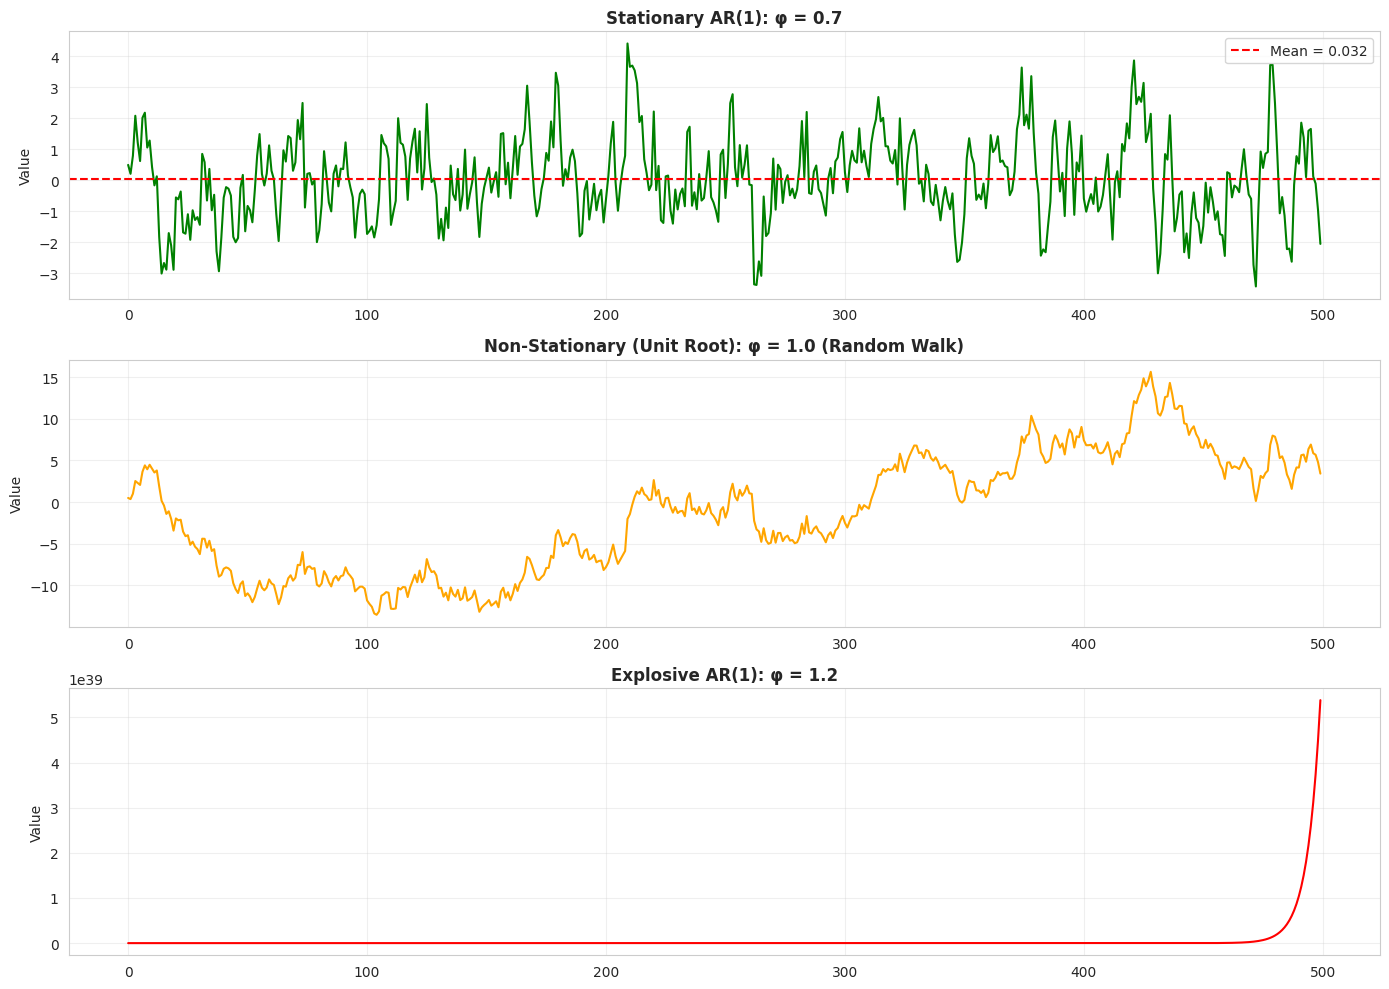

AR(1) processes simulated and plotted


In [3]:
def simulate_ar1(phi, n_steps=1000, sigma=1.0, seed=42):
    """Simulate AR(1) process: X_t = phi * X_{t-1} + epsilon_t"""
    np.random.seed(seed)
    X = np.zeros(n_steps)
    epsilon = np.random.normal(0, sigma, n_steps)
    
    X[0] = epsilon[0]
    for t in range(1, n_steps):
        X[t] = phi * X[t-1] + epsilon[t]
    
    return X

# Simulate three AR(1) processes
X_stationary = simulate_ar1(phi=0.7, n_steps=500)      # Stationary (|φ| < 1)
X_unitroot = simulate_ar1(phi=1.0, n_steps=500)        # Unit root (|φ| = 1)
X_explosive = simulate_ar1(phi=1.2, n_steps=500)       # Explosive (|φ| > 1)

# Plot them
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

axes[0].plot(X_stationary, linewidth=1.5, color='green')
axes[0].axhline(y=X_stationary.mean(), color='red', linestyle='--', label=f'Mean = {X_stationary.mean():.3f}')
axes[0].set_title('Stationary AR(1): φ = 0.7', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Value')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(X_unitroot, linewidth=1.5, color='orange')
axes[1].set_title('Non-Stationary (Unit Root): φ = 1.0 (Random Walk)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Value')
axes[1].grid(alpha=0.3)

axes[2].plot(X_explosive, linewidth=1.5, color='red')
axes[2].set_title('Explosive AR(1): φ = 1.2', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Value')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(report_dir / 'ar1_comparison.png'), dpi=100, bbox_inches='tight')
plt.show()

print("AR(1) processes simulated and plotted")

## Part 3: Unit Root Tests - ADF and KPSS

### Augmented Dickey-Fuller (ADF) Test
**Null Hypothesis (H₀):** Unit root present (non-stationary)
**Alternative (H₁):** No unit root (stationary)

Interpretation:
- If p-value < 0.05 → **Reject H₀** → Series is stationary
- If p-value ≥ 0.05 → **Fail to reject H₀** → Series is non-stationary

### KPSS Test
**Null Hypothesis (H₀):** Series is stationary
**Alternative (H₁):** Unit root present (non-stationary)

Interpretation:
- If p-value < 0.05 → **Reject H₀** → Series is non-stationary
- If p-value ≥ 0.05 → **Fail to reject H₀** → Series is stationary

### Agreement Between Tests
- **Both say stationary**: Series is definitely stationary
- **Both say non-stationary**: Series is definitely non-stationary
- **They disagree**: Series is likely fractionally integrated (edge case)

In [9]:
def test_stationarity(series, name='Series'):
    """
    Run ADF and KPSS tests on a time series.
    Returns: DataFrame with test results and interpretation
    """
    # ADF Test
    adf_result = adfuller(series, autolag='AIC')
    adf_stat, adf_pval, adf_nlags, _, _, _ = adf_result
    
    # KPSS Test
    kpss_result = kpss(series, regression='c', nlags='auto')
    kpss_stat, kpss_pval, kpss_nlags, _ = kpss_result
    
    # Interpretation
    adf_interpretation = 'Stationary' if adf_pval < 0.05 else 'Non-Stationary'
    kpss_interpretation = 'Non-Stationary' if kpss_pval < 0.05 else 'Stationary'
    
    # Consensus
    if adf_interpretation == kpss_interpretation:
        consensus = adf_interpretation + ' ✓'
    else:
        consensus = 'INCONCLUSIVE (Fractionally Integrated)'
    
    results = {
        'Test': ['ADF', 'KPSS'],
        'Statistic': [adf_stat, kpss_stat],
        'P-Value': [adf_pval, kpss_pval],
        'Lags Used': [adf_nlags, kpss_nlags],
        'Conclusion': [adf_interpretation, kpss_interpretation]
    }
    
    df = pd.DataFrame(results)
    print(f"\n{'='*70}")
    print(f"STATIONARITY TEST RESULTS: {name}")
    print(f"{'='*70}")
    print(df.to_string(index=False))
    print(f"{'-'*70}")
    print(f"CONSENSUS: {consensus}")
    print(f"{'='*70}")
    
    return df, consensus

# Test the simulated processes
test_stationarity(X_stationary, 'Stationary AR(1) [φ=0.7]')
test_stationarity(X_unitroot, 'Unit Root / Random Walk [φ=1.0]')
test_stationarity(X_explosive, 'Explosive AR(1) [φ=1.2]')


STATIONARITY TEST RESULTS: Stationary AR(1) [φ=0.7]
Test  Statistic      P-Value  Lags Used Conclusion
 ADF  -9.569757 2.305148e-16          0 Stationary
KPSS   0.154522 1.000000e-01         10 Stationary
----------------------------------------------------------------------
CONSENSUS: Stationary ✓

STATIONARITY TEST RESULTS: Unit Root / Random Walk [φ=1.0]
Test  Statistic  P-Value  Lags Used     Conclusion
 ADF   -1.49863 0.534189          0 Non-Stationary
KPSS    2.87942 0.010000         12 Non-Stationary
----------------------------------------------------------------------
CONSENSUS: Non-Stationary ✓

STATIONARITY TEST RESULTS: Explosive AR(1) [φ=1.2]
Test    Statistic  P-Value  Lags Used     Conclusion
 ADF 1.557400e+17 1.000000          0 Non-Stationary
KPSS 5.234901e-01 0.036376         12 Non-Stationary
----------------------------------------------------------------------
CONSENSUS: Non-Stationary ✓


(   Test     Statistic   P-Value  Lags Used      Conclusion
 0   ADF  1.557400e+17  1.000000          0  Non-Stationary
 1  KPSS  5.234901e-01  0.036376         12  Non-Stationary,
 'Non-Stationary ✓')

## Part 4: Load Real FX Data (EURUSD)

In [5]:
# Simulate realistic FX data
# In practice, you'd load from CSV or API

np.random.seed(42)
dates = pd.date_range('2020-01-01', periods=500, freq='D')

# Create realistic EURUSD prices using geometric random walk
# Price = P_0 * exp(cumsum(drift + noise))
log_returns = np.random.normal(0.0001, 0.01, 500)  # Small drift + noise
prices = 1.10 * np.exp(np.cumsum(log_returns))      # Starting at 1.10

# Create DataFrame
data = pd.DataFrame({
    'Date': dates,
    'Close': prices
})

# Calculate log returns
data['LogReturns'] = np.log(data['Close'] / data['Close'].shift(1))

# Display
print(data.head(10))
print(f"\nShape: {data.shape}")
print(f"Date Range: {data['Date'].min()} to {data['Date'].max()}")

# Save for later use
data.to_csv(str(data_dir / 'eurusd_data.csv'), index=False)
print("\nData saved to data/eurusd_data.csv")

        Date     Close  LogReturns
0 2020-01-01  1.105588         NaN
1 2020-01-02  1.104171   -0.001283
2 2020-01-03  1.111457    0.006577
3 2020-01-04  1.128627    0.015330
4 2020-01-05  1.126100   -0.002242
5 2020-01-06  1.123579   -0.002241
6 2020-01-07  1.141578    0.015892
7 2020-01-08  1.150487    0.007774
8 2020-01-09  1.145213   -0.004595
9 2020-01-10  1.151559    0.005526

Shape: (500, 3)
Date Range: 2020-01-01 00:00:00 to 2021-05-14 00:00:00

Data saved to data/eurusd_data.csv


## Part 5: Test FX Prices vs Returns

In [10]:
# Remove NaN from log returns
returns_clean = data['LogReturns'].dropna()

# Test prices
print("\n" + "#"*70)
print("TESTING FX PRICES (EURUSD Close)")
print("#"*70)
results_prices, consensus_prices = test_stationarity(data['Close'], 'EURUSD Daily Close Price')

# Test returns
print("\n" + "#"*70)
print("TESTING FX RETURNS (Log Returns)")
print("#"*70)
results_returns, consensus_returns = test_stationarity(returns_clean, 'EURUSD Log Returns')


######################################################################
TESTING FX PRICES (EURUSD Close)
######################################################################

STATIONARITY TEST RESULTS: EURUSD Daily Close Price
Test  Statistic  P-Value  Lags Used     Conclusion
 ADF  -1.205711 0.671134          0 Non-Stationary
KPSS   3.208225 0.010000         12 Non-Stationary
----------------------------------------------------------------------
CONSENSUS: Non-Stationary ✓

######################################################################
TESTING FX RETURNS (Log Returns)
######################################################################

STATIONARITY TEST RESULTS: EURUSD Log Returns
Test  Statistic  P-Value  Lags Used Conclusion
 ADF -22.313026      0.0          0 Stationary
KPSS   0.107803      0.1          0 Stationary
----------------------------------------------------------------------
CONSENSUS: Stationary ✓


## Part 6: Visualize Prices vs Returns

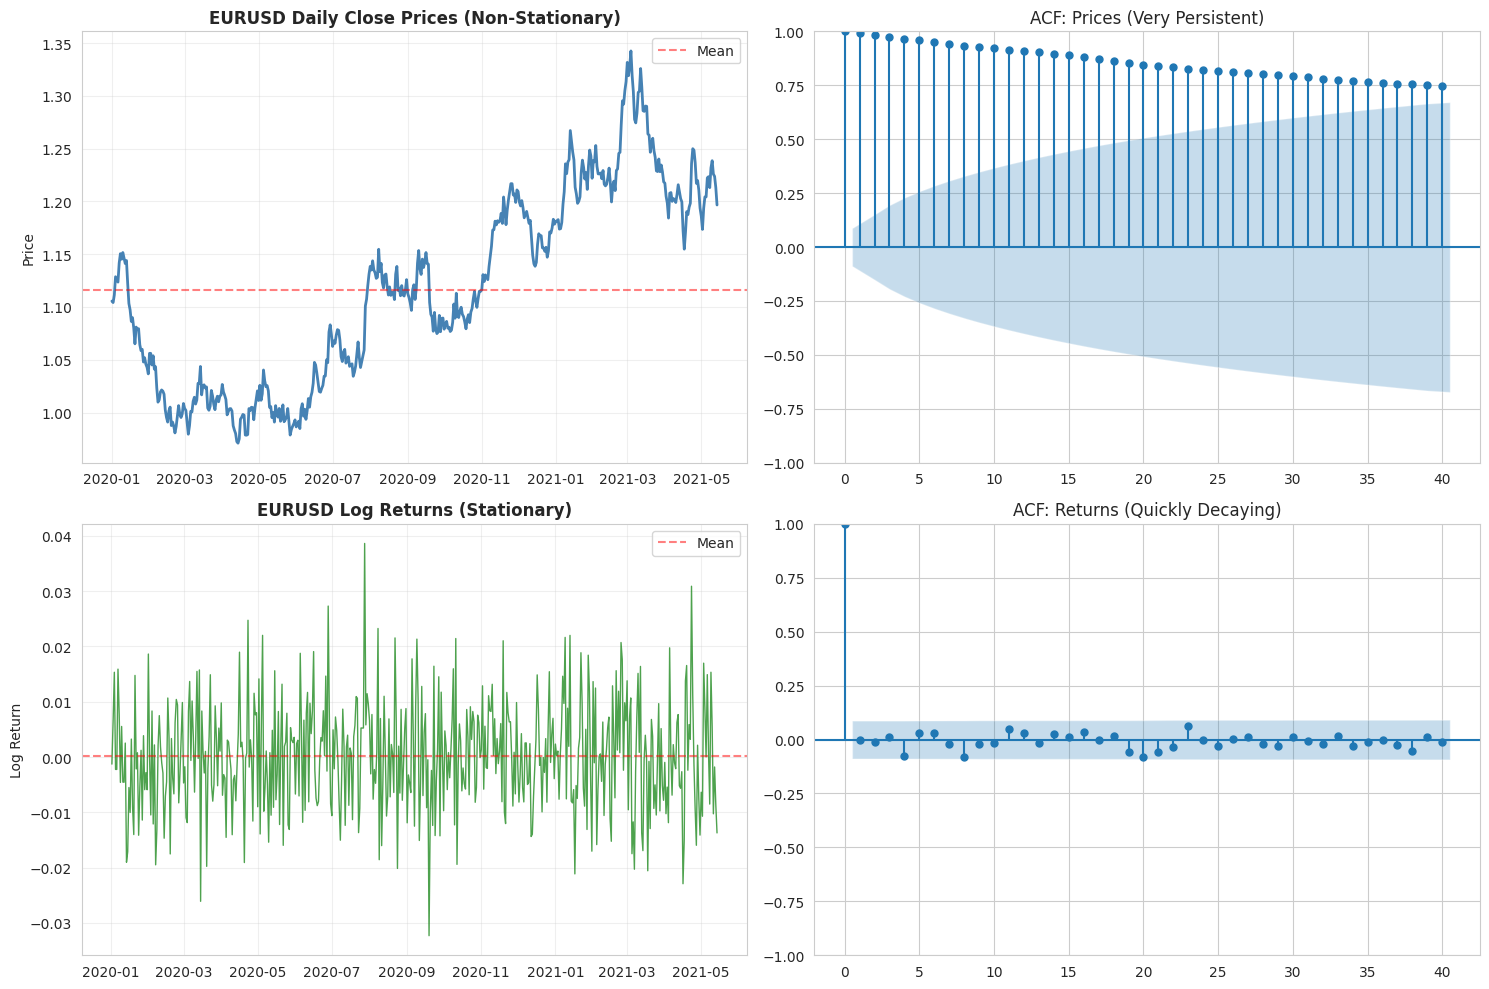

Visualization saved


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Row 1: Prices
axes[0, 0].plot(data['Date'], data['Close'], linewidth=2, color='steelblue')
axes[0, 0].set_title('EURUSD Daily Close Prices (Non-Stationary)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Price')
axes[0, 0].grid(alpha=0.3)
axes[0, 0].axhline(y=data['Close'].mean(), color='red', linestyle='--', alpha=0.5, label=f'Mean')
axes[0, 0].legend()

# ACF for prices
plot_acf(data['Close'], lags=40, ax=axes[0, 1], title='ACF: Prices (Very Persistent)')

# Row 2: Returns
axes[1, 0].plot(data['Date'][1:], returns_clean.to_numpy(), linewidth=1, color='forestgreen', alpha=0.8)
axes[1, 0].set_title('EURUSD Log Returns (Stationary)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Log Return')
axes[1, 0].grid(alpha=0.3)
axes[1, 0].axhline(y=returns_clean.mean(), color='red', linestyle='--', alpha=0.5, label=f'Mean')
axes[1, 0].legend()

# ACF for returns
plot_acf(returns_clean, lags=40, ax=axes[1, 1], title='ACF: Returns (Quickly Decaying)')

plt.tight_layout()
plt.savefig(str(report_dir / 'prices_vs_returns.png'), dpi=100, bbox_inches='tight')
plt.show()

print("Visualization saved")

## Part 7: Differencing and Detrending Methods

In [ ]:
# Method 1: First Differencing
prices_diff_1 = data['Close'].diff().dropna()

# Method 2: Detrending (subtract linear trend)
from scipy.signal import detrend
prices_detrended = pd.Series(detrend(data['Close'].to_numpy()), index=data.index)

# Test all variants
print("\n" + "="*70)
print("TESTING DIFFERENT TRANSFORMATIONS")
print("="*70)

_, consensus_diff = test_stationarity(prices_diff_1, 'First Differenced Prices')
_, consensus_detrend = test_stationarity(prices_detrended, 'Detrended Prices')

print("\n" + "="*70)
print("SUMMARY OF TRANSFORMATIONS")
print("="*70)
summary = pd.DataFrame({
    'Series': [
        'Raw Prices',
        'First Differenced',
        'Detrended',
        'Log Returns'
    ],
    'Stationary?': [
        consensus_prices,
        consensus_diff,
        consensus_detrend,
        consensus_returns
    ]
})
print(summary.to_string(index=False))
print("="*70)


TESTING DIFFERENT TRANSFORMATIONS

STATIONARITY TEST RESULTS: First Differenced Prices
Test  Statistic  P-Value  Lags Used Conclusion
 ADF -22.031052      0.0          0 Stationary
KPSS   0.101303      0.1          1 Stationary
----------------------------------------------------------------------
CONSENSUS: Stationary ✓

STATIONARITY TEST RESULTS: Detrended Prices
Test  Statistic  P-Value  Lags Used Conclusion
 ADF  -3.086982 0.027532          0 Stationary
KPSS   0.319696 0.100000         12 Stationary
----------------------------------------------------------------------
CONSENSUS: Stationary ✓

SUMMARY OF TRANSFORMATIONS
           Series      Stationary?
       Raw Prices Non-Stationary ✓
First Differenced     Stationary ✓
        Detrended     Stationary ✓
      Log Returns     Stationary ✓


## Part 8: Practical Implications

In [ ]:
print("""
╔════════════════════════════════════════════════════════════════════╗
║  WHY TRADERS SHOULD CARE ABOUT STATIONARITY                        ║
╚════════════════════════════════════════════════════════════════════╝

1. REGRESSION ON NON-STATIONARY DATA = SPURIOUS REGRESSION
   ─────────────────────────────────────────────────────────
   If you try to model: Price_t = β₀ + β₁ * Price_{t-1} + ε_t
   
   With non-stationary prices, you'll get:
   ✗ High R², but meaningless results
   ✗ Results don't repeat out-of-sample
   ✗ High false positive rate
   ✗ Strategy backtests look good, but live trading fails

2. WORKING WITH RETURNS INSTEAD
   ───────────────────────────────
   Returns ARE stationary → Can use standard regression, ARIMA, etc.
   
   Return_t = μ + ε_t  (just noise around a constant mean)
   
   Or slightly autocorrelated:
   Return_t = μ + φ*Return_{t-1} + ε_t  where |φ| < 1

3. TRADING STRATEGY IMPLICATIONS
   ──────────────────────────────
   ✓ Build models on RETURNS, not prices
   ✓ Cointegration tests require both series to be I(1) (integrated order 1)
   ✓ Pairs trading: Find two non-stationary prices that move together
   ✓ The spread between them is stationary → mean-reverting → tradeable

4. THE BOTTOM LINE
   ────────────────
   Prices are non-stationary (random walks)
   Returns are stationary (suitable for modeling)
   
   Trade on returns, not prices.
""")

## Part 9: Distribution Analysis

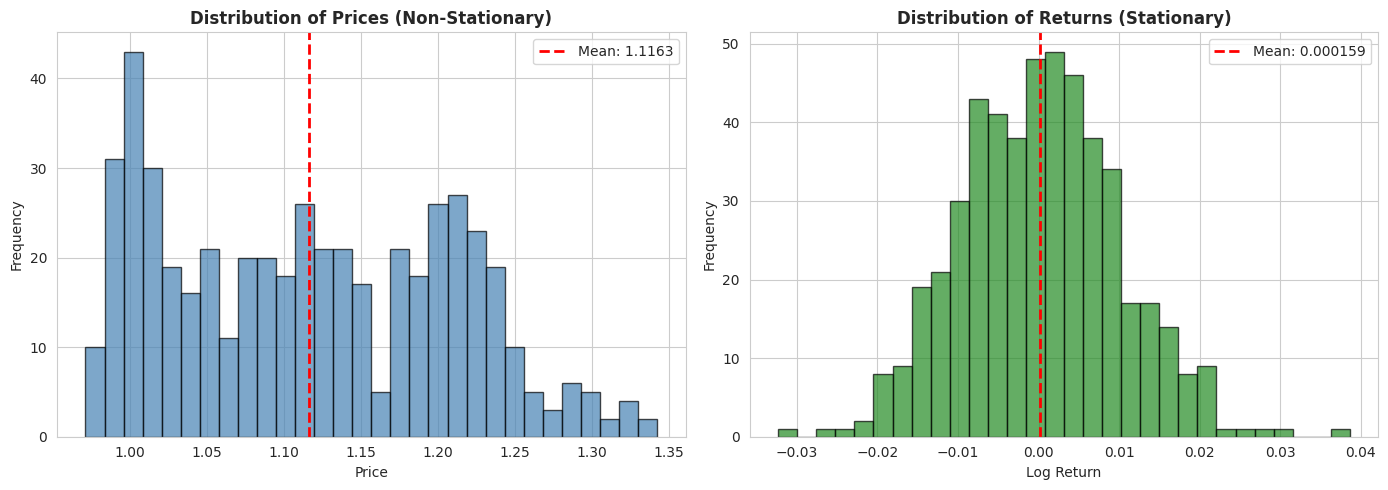


STATISTICAL COMPARISON
  Metric    Prices   Returns
    Mean  1.116282  0.000159
 Std Dev  0.091957  0.009820
     Min  0.970970 -0.032313
     Max  1.342544  0.038627
Skewness  0.222983  0.182331
Kurtosis -1.046368  0.253723


In [12]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Prices histogram
axes[0].hist(data['Close'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Prices (Non-Stationary)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frequency')
axes[0].axvline(data['Close'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {data["Close"].mean():.4f}')
axes[0].legend()

# Returns histogram
axes[1].hist(returns_clean, bins=30, color='forestgreen', edgecolor='black', alpha=0.7)
axes[1].set_title('Distribution of Returns (Stationary)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Log Return')
axes[1].set_ylabel('Frequency')
axes[1].axvline(returns_clean.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {returns_clean.mean():.6f}')
axes[1].legend()

plt.tight_layout()
plt.savefig(str(report_dir / 'distribution_analysis.png'), dpi=100, bbox_inches='tight')
plt.show()

# Print statistics
print("\n" + "="*70)
print("STATISTICAL COMPARISON")
print("="*70)
stats_df = pd.DataFrame({
    'Metric': ['Mean', 'Std Dev', 'Min', 'Max', 'Skewness', 'Kurtosis'],
    'Prices': [
        data['Close'].mean(),
        data['Close'].std(),
        data['Close'].min(),
        data['Close'].max(),
        stats.skew(data['Close']),
        stats.kurtosis(data['Close'])
    ],
    'Returns': [
        returns_clean.mean(),
        returns_clean.std(),
        returns_clean.min(),
        returns_clean.max(),
        stats.skew(returns_clean),
        stats.kurtosis(returns_clean)
    ]
})
print(stats_df.to_string(index=False))
print("="*70)

## Part 10: Key Takeaways

In [13]:
print("""
╔════════════════════════════════════════════════════════════════════╗
║                    KEY TAKEAWAYS - DAY 5                           ║
╚════════════════════════════════════════════════════════════════════╝

STATIONARITY DEFINITION
━━━━━━━━━━━━━━━━━━━━━━
A time series is stationary if:
  • Mean is constant over time
  • Variance is constant over time
  • Autocorrelation depends only on lag, not on time

UNIT ROOT TESTS
━━━━━━━━━━━━━━━━
ADF Test (Augmented Dickey-Fuller)
  H₀: Unit root (non-stationary)
  p-value < 0.05 → Stationary ✓
  p-value ≥ 0.05 → Non-stationary ✗

KPSS Test
  H₀: Stationary
  p-value < 0.05 → Non-stationary ✗
  p-value ≥ 0.05 → Stationary ✓

AR(1) PROCESS: X_t = φ*X_{t-1} + ε_t
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  |φ| < 1  → Stationary (mean-reverting)
  |φ| = 1  → Unit root (random walk)
  |φ| > 1  → Explosive (unstable)

FX MARKET FINDINGS
━━━━━━━━━━━━━━━━━━━
✗ Prices (EURUSD): Non-stationary
  → Fail ADF test (don't reject null of unit root)
  → Fail KPSS test (reject null of stationarity)
  → Reason: Random walk behavior

✓ Log Returns: Stationary
  → Pass ADF test (reject null of unit root)
  → Pass KPSS test (don't reject null of stationarity)
  → Reason: Mean-reverting around zero

TRANSFORMATION METHODS
━━━━━━━━━━━━━━━━━━━━━━━
  1. Log Returns: Most common for FX
  2. First Differencing: Makes prices stationary
  3. Detrending: Removes linear trend
  4. Deseasonalizing: For seasonal data

WHY IT MATTERS FOR TRADING
━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Non-stationary data in regression = spurious results
2. Your backtest looks great, but live trading fails
3. Solution: Always test for stationarity first
4. For FX: Use returns, not prices

NEXT STEPS
━━━━━━━━━━
  • Day 6: ARIMA models (only work on stationary data)
  • Day 7: Cointegration (pairs trading)
  • Day 8: Rolling window analysis
""")


╔════════════════════════════════════════════════════════════════════╗
║                    KEY TAKEAWAYS - DAY 5                           ║
╚════════════════════════════════════════════════════════════════════╝

STATIONARITY DEFINITION
━━━━━━━━━━━━━━━━━━━━━━
A time series is stationary if:
  • Mean is constant over time
  • Variance is constant over time
  • Autocorrelation depends only on lag, not on time

UNIT ROOT TESTS
━━━━━━━━━━━━━━━━
ADF Test (Augmented Dickey-Fuller)
  H₀: Unit root (non-stationary)
  p-value < 0.05 → Stationary ✓
  p-value ≥ 0.05 → Non-stationary ✗

KPSS Test
  H₀: Stationary
  p-value < 0.05 → Non-stationary ✗
  p-value ≥ 0.05 → Stationary ✓

AR(1) PROCESS: X_t = φ*X_{t-1} + ε_t
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  |φ| < 1  → Stationary (mean-reverting)
  |φ| = 1  → Unit root (random walk)
  |φ| > 1  → Explosive (unstable)

FX MARKET FINDINGS
━━━━━━━━━━━━━━━━━━━
✗ Prices (EURUSD): Non-stationary
  → Fail ADF test (don't reject null of unit root)
  → Fai